In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split#function to split dataset
from sklearn.preprocessing import StandardScaler#scales data (normalization)
from sklearn.linear_model import LogisticRegression#Used for classification (0 or 1)
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score


In [3]:
df = pd.read_csv("Social_Network_Ads.csv")
# check the dataset for missing values and perform EDA
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.tail()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


,User ID,Gender,Age,EstimatedSalary,Purchased
count,4.000000e+02,400,400.000000,400.000000,400.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,204,NaN,NaN,NaN
mean,1.569154e+07,NaN,37.655000,69742.500000,0.357500
std,7.165832e+04,NaN,10.482877,34096.960282,0.479864
min,1.556669e+07,NaN,18.000000,15000.000000,0.000000
25%,1.562676e+07,NaN,29.750000,43000.000000,0.000000
50%,1.569434e+07,NaN,37.000000,70000.000000,0.000000
75%,1.575036e+07,NaN,46.000000,88000.000000,1.000000


In [5]:
df.shape
df.size
df.ndim
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [6]:
df.isnull()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
395,False,False,False,False,False
396,False,False,False,False,False
397,False,False,False,False,False
398,False,False,False,False,False


In [7]:
#select the features and target variable
# Selecting independent variables (features) and dependent variable (target)
X = df[['Age', 'EstimatedSalary']]  # Assuming these are features
y = df['Purchased']  # Target variable


In [8]:
# Splitting dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)



Training Set Size: (320, 2)
Testing Set Size: (80, 2)


In [9]:
# Train the Logistic Regression model Model Training
model = LogisticRegression()
model.fit(X_train, y_train)
#Model is now trained
# Make predictions on the test set
y_pred = model.predict(X_test)


In [10]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")
#compares actual vs predicted
#gives correct percentage


Accuracy: 0.8875


In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract values
TN, FP, FN, TP = cm.ravel()
#.ravel() → converts matrix into 1D array
# Print confusion matrix and extracted values
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")
print(f"False Negatives (FN): {FN}")


Confusion Matrix:
[[50  2]
 [ 7 21]]

True Positives (TP): 21
False Positives (FP): 2
True Negatives (TN): 50
False Negatives (FN): 7


In [12]:
precision = precision_score(y_test, y_pred)
print(f"\nPrecision: {precision:.4f}")
#Out of predicted positives, how many are correct


Precision: 0.9130


In [14]:
recall = recall_score(y_test, y_pred)
print(f"\nRecall: {recall:.4f}")
#Out of actual positives, how many were found


Recall: 0.7500


In [15]:
error_rate = 1 - accuracy
print(f"\nError Rate: {error_rate:.4f}")
#Wrong predictions percentage


Error Rate: 0.1125


In [16]:
f1 = f1_score(y_test, y_pred)
print(f"\nF1 Score: {f1:.4f}")
#Balance between precision and recall


F1 Score: 0.8235


In [17]:
# Display detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



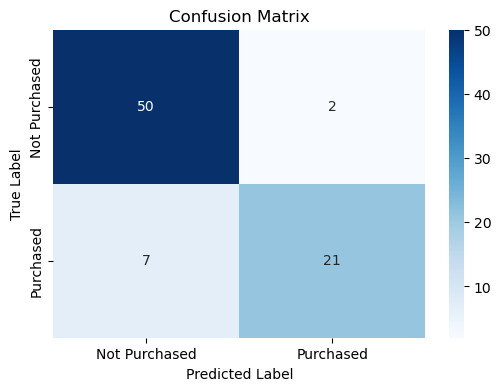

In [18]:
# Visualizing confusion matrix heatmap → visual matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Purchased", "Purchased"], yticklabels=["Not Purchased", "Purchased"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
